# FDSI benchmark: 1. Calibration

`CBSS` (convolutive blind source separation) decomposes the first 5 s of each recording, a
steady isometric hold, into motor units: the whitening and separation vectors, and each unit's
spike centroids. In simulation the ground truth is known, so `select_supervised` keeps only the
units matching a simulated motor unit with a rate of agreement (RoA) of at least 90%. Every
later stage tracks these same units.

The stored figures can be read without running anything. Running the walkthrough needs the
FDSI recordings (`adapt-decomp-data get fdsi_benchmark-data`, about 10 GB); the summary at the
end reads only `benchmarks/fdsi/results/`, part of the repository.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents) if (p / "benchmarks" / "fdsi").is_dir()
)
sys.path.insert(0, str(REPO_ROOT))  # so that benchmarks.fdsi imports from any working directory

In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np

from adapt_decomp import CBSS, CBSSConfig
from adapt_decomp.utils import load_gt
from adapt_decomp.utils.plots import plot_metric_heatmap, plot_spikes
from benchmarks.fdsi import fdsi, pipeline, report

cfg = pipeline.load_config()
DATA_ROOT, FS = pipeline.REPO_ROOT / cfg["data_root"], cfg["grid"]["fs"]
CAL_END = pipeline.cal_end(cfg)  # samples of the calibration window
CONDITIONS, SNR_LEVELS = cfg["grid"]["conditions"], cfg["grid"]["snr_levels"]

## One recording

Subject 1's 40 s triangular ramp at 30 dB SNR: calibrate on its first 5 s, then keep the units
that match the ground truth.

In [3]:
rec = fdsi.Recording("sub-01", "triangular-ramp40s", 30)
emg_calib = fdsi.load_raw_emg(DATA_ROOT, rec)[:CAL_END]  # (samples, channels)
ts_calib = np.arange(CAL_END) / FS
gt_calib = load_gt(fdsi.gt_spikes_path(DATA_ROOT, rec.sub, rec.cond), n_samples=CAL_END)

cbss_config = CBSSConfig(**cfg["calibration"]["cbss_config"])
calibration = CBSS(cbss_config).decompose(emg_calib, ts_calib)
n_found = calibration.spikes.shape[1]
calibration = calibration.select_supervised(
    gt_calib, roa_th=0.9, tol_spike_ms=cfg["grid"]["tol_spike_ms"], fs=FS
)
print(f"{rec.stub}: {n_found} units found, {calibration.spikes.shape[1]} match the ground truth")

sub-01_FDSI_triangular-ramp40s_snr30dB: 110 units found, 13 match the ground truth


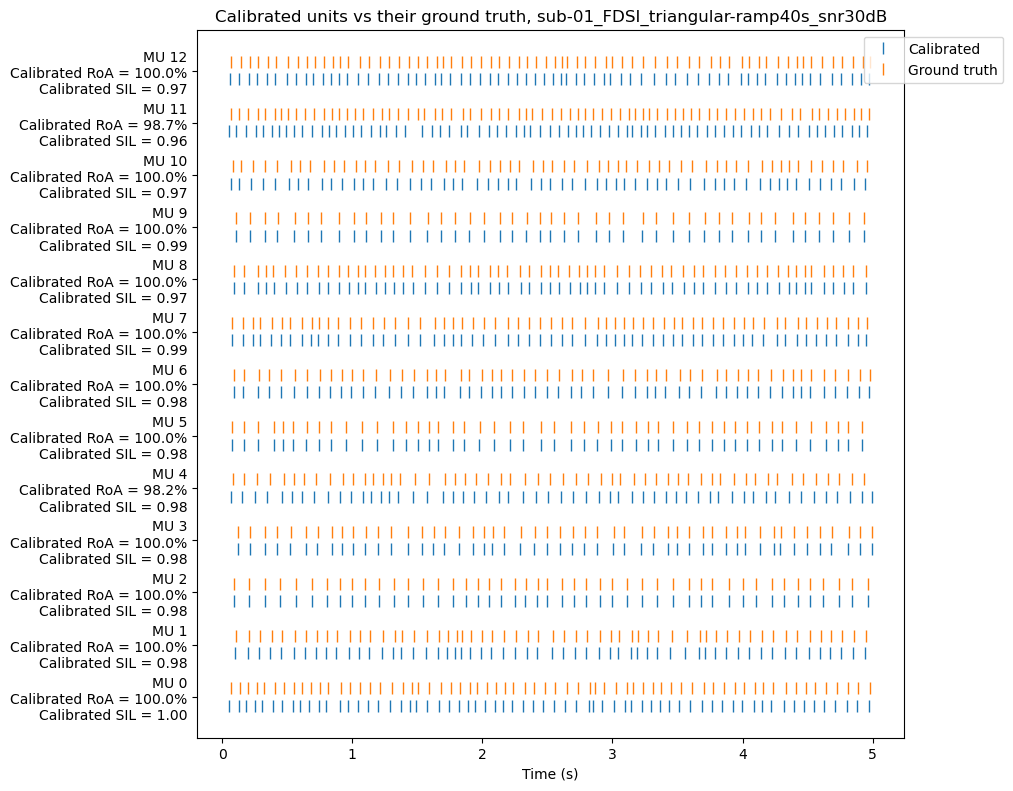

In [4]:
ax = plot_spikes(
    {
        "Calibrated": calibration.spikes,
        "Ground truth": gt_calib[:, calibration.gt_matched_indices],
    },
    ts_calib,
    roa={"Calibrated": calibration.roa},
    sil={"Calibrated": calibration.sil},
)
ax.set_title(f"Calibrated units vs their ground truth, {rec.stub}")
plt.show()

## Every recording

The previous code is looped in `benchmarks/fdsi/pipeline.py` to run across all contractions. A task whose output already exists is skipped, so set `RUN`
to `True` to compute only what is missing. Outside a notebook, the same stage runs with
`python -m benchmarks.fdsi calibrate --workers 8` (add `--quick` for the small check of
`config.yaml`'s `quick` section), or on a PBS cluster as array jobs with
`bash benchmarks/fdsi/pbs/submit.sh`.

In [ ]:
RUN = False
if RUN:
    pipeline.run(cfg, "calibrate", n_workers=os.cpu_count())

## Summary

Per condition and SNR, averaged over subjects: the units kept per recording, their RoA over the
calibration window, and how many have a silhouette (SIL) of at least 0.9, the usual quality
threshold without ground truth. Lower SNR leaves fewer units.

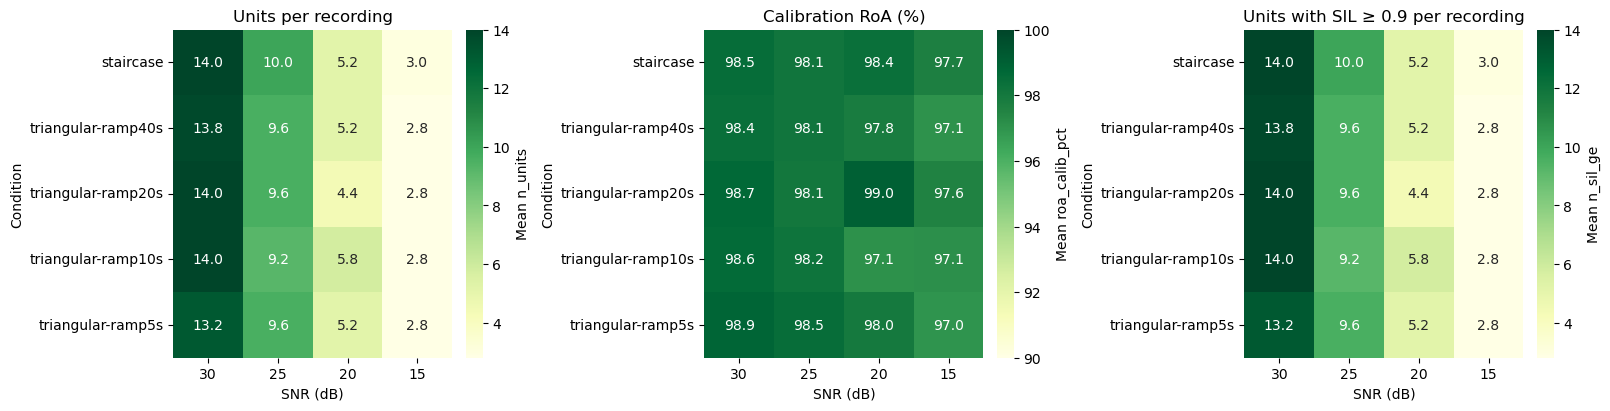

In [6]:
calib_units = report.load_results(cfg["version"])["calibration_units"]
per_recording = report.units_per_recording(
    calib_units, sil_col="sil_calib", roa_col="roa_calib", by=["recording", "condition", "snr"]
).assign(config="Calibration")

fig, axs = plt.subplots(1, 3, figsize=(16, 4), layout="constrained")
plot_metric_heatmap(per_recording, "n_units", ["Calibration"], CONDITIONS, SNR_LEVELS, axs=axs[[0]])
plot_metric_heatmap(
    calib_units.assign(config="Calibration"),
    "roa_calib_pct",
    ["Calibration"],
    CONDITIONS,
    SNR_LEVELS,
    vmin=90,
    vmax=100,
    axs=axs[[1]],
)
plot_metric_heatmap(
    per_recording, "n_sil_ge", ["Calibration"], CONDITIONS, SNR_LEVELS, axs=axs[[2]]
)
for ax, title in zip(
    axs, ["Units per recording", "Calibration RoA (%)", "Units with SIL ≥ 0.9 per recording"]
):
    ax.set_title(title)
plt.show()

Next: [2. Search](2_search.ipynb) the adaptation's hyperparameters.